## Download data from kaggle

In [118]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("chazzer/smiling-or-not-face-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'smiling-or-not-face-data' dataset.
Path to dataset files: /kaggle/input/smiling-or-not-face-data


## Impoer Libraries

In [119]:
import os
import glob
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import GridSearchCV

## List all folders inside of the path

In [120]:
print(os.listdir(path))

['smile', 'non_smile', 'test']


In [121]:
non_smile_path=os.path.join(path,"non_smile")
smile_path=os.path.join(path,"smile")
test_path=os.path.join(path,"test")

In [122]:
smile=glob.glob(os.path.join(smile_path,"*.jpg"))
non_smile=glob.glob(os.path.join(non_smile_path,"*.jpg"))
test=glob.glob(os.path.join(test_path,"*.jpg"))

In [123]:
print("No of smile",len(smile))
print("No of non smile",len(non_smile))
print("No of test",len(test))

No of smile 600
No of non smile 603
No of test 12030


## Data Cleaning

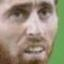

In [124]:
Image.open(non_smile[15])

In [125]:
data=[]
labels=[]

In [126]:
#Smile images
for image in non_smile:
  img=Image.open(image)
  img=img.convert('L')
  img=np.array(img).flatten()
  data.append(img)
  labels.append(0)

In [127]:
len(data),len(labels)

(603, 603)

In [128]:
#for smile images
for image in smile:
  img=Image.open(image)
  img=img.convert('L')
  img=np.array(img).flatten()
  data.append(img)
  labels.append(1)

In [129]:
len(data),len(labels)

(1203, 1203)

In [130]:
x=np.array(data)
y=np.array(labels)

## Model DEVELOPMENT

In [131]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,shuffle=True)

In [132]:
x_train.shape

(962, 4096)

In [133]:
x_test.shape

(241, 4096)

In [134]:
x_train[12]

array([138, 143, 150, ..., 111, 113, 117], dtype=uint8)

In [135]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

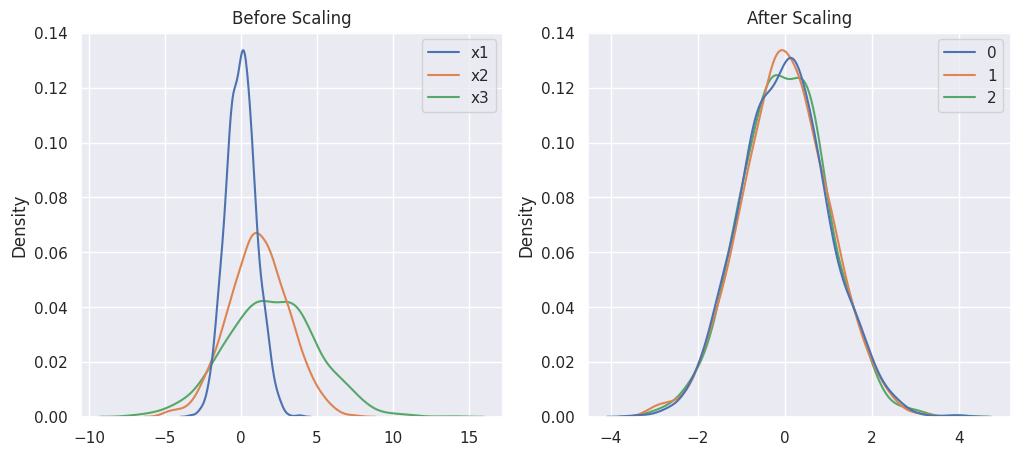

In [136]:
sns.set_theme(style="darkgrid")
# create sample different features and variances
np.random.seed(42)
x1=np.random.normal(loc=0, scale=1, size=1000)
x2=np.random.normal(loc=1, scale=2, size=1000)
x3=np.random.normal(loc=2, scale=3, size=1000)
x_train=pd.DataFrame({'x1':x1,'x2':x2,'x3':x3})

#plot the graphs
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
#after scaling
ax2.set_title("After Scaling")
sns.kdeplot(data=scaler.fit_transform(x_train),ax=ax2)
#before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(data=x_train,ax=ax1)

plt.show()


In [137]:
model=LogisticRegression(solver='saga',max_iter=1000)
model.fit(x_train_scaled,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=1000, solver='saga')

In [138]:
y_pred=model.predict(x_test_scaled)

In [139]:
y_pred

array([1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1])

In [140]:
accuarcy=accuracy_score(y_test,y_pred)
print(f"model accuracy  {accuarcy}")
print(f"confusion matrix {confusion_matrix(y_test,y_pred)}")
print(f"classification report {classification_report(y_test,y_pred)}")


model accuracy  0.9004149377593361
confusion matrix [[113  13]
 [ 11 104]]
classification report               precision    recall  f1-score   support

           0       0.91      0.90      0.90       126
           1       0.89      0.90      0.90       115

    accuracy                           0.90       241
   macro avg       0.90      0.90      0.90       241
weighted avg       0.90      0.90      0.90       241



## Model Deployement

In [141]:
from pickle import dump
dump(model,open('model.pkl','wb'))
dump(scaler,open('scaler.pkl','wb'))